# QELM vs QK

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import myQMLfunctions as myQML

In [2]:
rho_training, rho_test, expe_training_X, expe_training_Y, expe_training_Z, expe_test_X, expe_test_Y, expe_test_Z = myQML.generate_dataset_pauli(100, 1000)

In [3]:
print(rho_training.shape)
print(rho_training)
print('\n')
print(rho_training[0])

(100, 2, 2)
[[[ 0.45832473+0.j          0.08794504+0.4075993j ]
  [ 0.08794504-0.4075993j   0.54167527+0.j        ]]

 [[ 0.7286615 +0.j          0.07630965-0.42418463j]
  [ 0.07630965+0.42418463j  0.2713385 +0.j        ]]

 [[ 0.85010981+0.j          0.15331963+0.21017187j]
  [ 0.15331963-0.21017187j  0.14989019+0.j        ]]

 [[ 0.29301894+0.j          0.38757099-0.10256412j]
  [ 0.38757099+0.10256412j  0.70698106+0.j        ]]

 [[ 0.37693925+0.j         -0.21689544-0.32211117j]
  [-0.21689544+0.32211117j  0.62306075+0.j        ]]

 [[ 0.37134787+0.j         -0.45476293+0.01752176j]
  [-0.45476293-0.01752176j  0.62865213+0.j        ]]

 [[ 0.65257743+0.j         -0.23734369+0.15225674j]
  [-0.23734369-0.15225674j  0.34742257+0.j        ]]

 [[ 0.89681633+0.j          0.0975929 -0.03107029j]
  [ 0.0975929 +0.03107029j  0.10318367+0.j        ]]

 [[ 0.16835469+0.j          0.00369962-0.17143156j]
  [ 0.00369962+0.17143156j  0.83164531+0.j        ]]

 [[ 0.52743968+0.j          0.3332

In [4]:
rho = myQML.generate_random_density_matrix(2)
print(rho)
print(np.trace(rho))

[[ 0.79678109-3.78407474e-19j -0.32913151+2.26906409e-01j]
 [-0.32913151-2.26906409e-01j  0.20321891+3.78407474e-19j]]
(0.9999999999999999-2.8888949165808538e-34j)


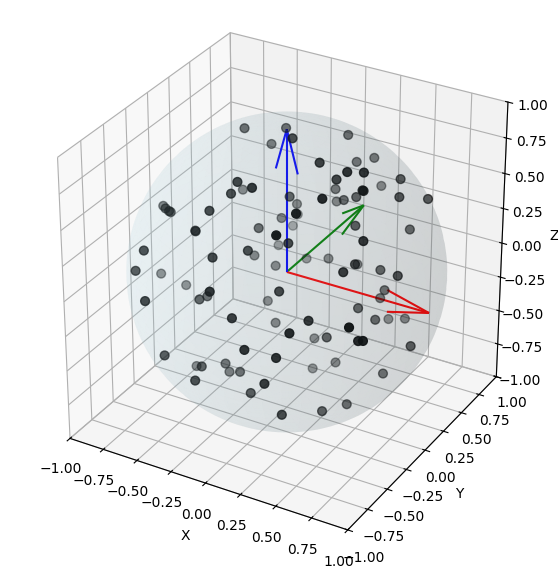

In [5]:
bloch_points_1 = [myQML.density_to_bloch(rho) for rho in rho_training]
myQML.plot_bloch_sphere(bloch_points_1)

In [6]:
kernelmodel = myQML.QuantumKernelRegression(regularization_lambda=0)
kernelmodel.fit(rho_training, expe_training_X)
predictions = kernelmodel.predict(rho_test)
print(f"\nPredictions on test data (first 5):\n{predictions[:5]}")
print(f"Original test labels (first 5):\n{expe_test_X[:5]}")

# Calculate Mean Squared Error on training data
mse = np.mean((predictions - expe_test_X)**2)
print(f"Mean Squared Error on training data: {mse:.4f}")

predictions_training = kernelmodel.predict(rho_training)
print(f"\nPredictions on training data (first 5):\n{predictions_training[:5]}")
print(f"Original training labels (first 5):\n{expe_training_X[:5]}")

Computing Gram matrix of size 100x100...
Gram matrix computation complete.
Inverting Gram matrix...
Gram matrix inverted successfully.
Model fitted: alpha (dual variables) computed.
Computing kernel matrix for 1000 test samples against 100 training samples...
Kernel matrix computation for test samples complete.
Prediction dimension is
(1000,)

Predictions on test data (first 5):
[28.3977512  31.51844498 38.16148673 21.20712453 26.96038038]
Original test labels (first 5):
[-0.03538977  0.48062116 -0.01695635 -0.23145594 -0.34514814]
Mean Squared Error on training data: 855.1292
Computing kernel matrix for 100 test samples against 100 training samples...
Kernel matrix computation for test samples complete.
Prediction dimension is
(100,)

Predictions on training data (first 5):
[13.73095823 48.2347507  28.39658625 34.04710387 34.23898437]
Original training labels (first 5):
[ 0.17589008  0.15261929  0.30663925  0.77514199 -0.43379088]


In [7]:
kernelmodel = myQML.QuantumKernelRegression(regularization_lambda=1e-5)
kernelmodel.fit(rho_training, expe_training_X)
predictions = kernelmodel.predict(rho_test)
print(f"\nPredictions on test data (first 5):\n{predictions[:5]}")
print(f"Original test labels (first 5):\n{expe_test_X[:5]}")

# Calculate Mean Squared Error on training data
mse = np.mean((predictions - expe_test_X)**2)
print(f"Mean Squared Error on training data: {mse:.4f}")

predictions_training = kernelmodel.predict(rho_training)
print(f"\nPredictions on training data (first 5):\n{predictions_training[:5]}")
print(f"Original training labels (first 5):\n{expe_training_X[:5]}")

Computing Gram matrix of size 100x100...
Gram matrix computation complete.
Inverting Gram matrix...
Gram matrix inverted successfully.
Model fitted: alpha (dual variables) computed.
Computing kernel matrix for 1000 test samples against 100 training samples...
Kernel matrix computation for test samples complete.
Prediction dimension is
(1000,)

Predictions on test data (first 5):
[-0.03538972  0.48062065 -0.01695627 -0.23145569 -0.34514775]
Original test labels (first 5):
[-0.03538977  0.48062116 -0.01695635 -0.23145594 -0.34514814]
Mean Squared Error on training data: 0.0000
Computing kernel matrix for 100 test samples against 100 training samples...
Kernel matrix computation for test samples complete.
Prediction dimension is
(100,)

Predictions on training data (first 5):
[ 0.17588984  0.15261921  0.30663891  0.77514117 -0.43379035]
Original training labels (first 5):
[ 0.17589008  0.15261929  0.30663925  0.77514199 -0.43379088]


In [8]:
num_realizations = 50
mse_values = []
for i in range(num_realizations):
    rho_training, rho_test, expe_training_X, expe_training_Y, expe_training_Z, expe_test_X, expe_test_Y, expe_test_Z = myQML.generate_dataset_pauli(100, 1000)
    kernelmodel = myQML.QuantumKernelRegression(regularization_lambda=0)
    kernelmodel.fit(rho_training, expe_training_X)
    predictions = kernelmodel.predict(rho_test)
    mse = np.mean((predictions - expe_test_X)**2)
    mse_values.append(mse)
     # Optional: Print progress every 10 steps so you know it's working
    if (i + 1) % 10 == 0:
        print(f"  Completed realization {i + 1}/{num_realizations} | Current MSE: {mse:.6f}")


print(f"Mean Squared Error across realizations: {np.mean(mse_values)}")

Computing Gram matrix of size 100x100...
Gram matrix computation complete.
Inverting Gram matrix...
Gram matrix inverted successfully.
Model fitted: alpha (dual variables) computed.
Computing kernel matrix for 1000 test samples against 100 training samples...
Kernel matrix computation for test samples complete.
Prediction dimension is
(1000,)
Computing Gram matrix of size 100x100...
Gram matrix computation complete.
Inverting Gram matrix...
Gram matrix inverted successfully.
Model fitted: alpha (dual variables) computed.
Computing kernel matrix for 1000 test samples against 100 training samples...
Kernel matrix computation for test samples complete.
Prediction dimension is
(1000,)
Computing Gram matrix of size 100x100...
Gram matrix computation complete.
Inverting Gram matrix...
Gram matrix inverted successfully.
Model fitted: alpha (dual variables) computed.
Computing kernel matrix for 1000 test samples against 100 training samples...
Kernel matrix computation for test samples complet

In [9]:
print(f"Mean Squared Error across realizations: {np.mean(mse_values)}")

Mean Squared Error across realizations: 10269.527463420518


In [10]:
num_realizations = 50
mse_values = []
for i in range(num_realizations):
    rho_training, rho_test, expe_training_X, expe_training_Y, expe_training_Z, expe_test_X, expe_test_Y, expe_test_Z = myQML.generate_dataset_pauli(100, 1000)
    kernelmodel_le = myQML.QuantumKernelRegression2(regularization_lambda=1e-6, num_shots=1000)
    
    kernelmodel_le.fit(rho_training, expe_training_X, "le")
    predictions = kernelmodel_le.predict(rho_test)
    mse = np.mean((predictions - expe_test_X)**2)
    mse_values.append(mse)
     # Optional: Print progress every 10 steps so you know it's working
    if (i + 1) % 10 == 0:
        print(f"  Completed realization {i + 1}/{num_realizations} | Current MSE: {mse:.6f}")


print(f"Mean Squared Error across realizations: {np.mean(mse_values)}")

  Completed realization 10/50 | Current MSE: 0.008377
  Completed realization 20/50 | Current MSE: 0.000862
  Completed realization 30/50 | Current MSE: 0.001230
  Completed realization 40/50 | Current MSE: 0.002176
  Completed realization 50/50 | Current MSE: 0.001216
Mean Squared Error across realizations: 0.1123544727862541


In [11]:
num_realizations = 50
mse_values = []
for i in range(num_realizations):
    rho_training, rho_test, expe_training_X, expe_training_Y, expe_training_Z, expe_test_X, expe_test_Y, expe_test_Z = myQML.generate_dataset_pauli(100, 1000)
    kernelmodel_swap = myQML.QuantumKernelRegression2(regularization_lambda=1e-6, num_shots=1000)
    kernelmodel_swap.fit(rho_training, expe_training_X, "le")
    predictions = kernelmodel_le.predict(rho_test)
    mse = np.mean((predictions - expe_test_X)**2)
    mse_values.append(mse)
     # Optional: Print progress every 10 steps so you know it's working
    if (i + 1) % 10 == 0:
        print(f"  Completed realization {i + 1}/{num_realizations} | Current MSE: {mse:.6f}")


print(f"Mean Squared Error across realizations: {np.mean(mse_values)}")

  Completed realization 10/50 | Current MSE: 0.001237
  Completed realization 20/50 | Current MSE: 0.001070
  Completed realization 30/50 | Current MSE: 0.001132
  Completed realization 40/50 | Current MSE: 0.001196
  Completed realization 50/50 | Current MSE: 0.001246
Mean Squared Error across realizations: 0.001163477516934941


In [ ]:

import matplotlib.pyplot as plt
import time

# --- 1. Dataset Generator ---
def generate_dataset(num_samples: int):
    """Generates 1-qubit states and Pauli-X expectation labels."""
    rhos = []
    labels = []
    sigma_x = np.array([[0, 1], [1, 0]])
    
    for _ in range(num_samples):
        rand_mat = np.random.rand(2, 2) + 1j * np.random.rand(2, 2)
        herm_mat = rand_mat + rand_mat.conj().T
        rho = (herm_mat @ herm_mat.conj().T)
        rho = rho / np.trace(rho)
        
        y = np.real(np.trace(rho @ sigma_x)) 
        rhos.append(rho)
        labels.append(y)
        
    return np.array(rhos), np.array(labels)

# --- 2. Experiment Setup ---
N_train_list = [10, 100, 1000, 5000, 10000]
N_test = 1000           # Keep test set size fixed to compare MSE fairly
num_shots = None       # Fixed finite statistics
num_realizations = 6  # Average over 20 runs

# Regularization must be relatively high due to 1000 shots of noise!
# If you get Singular Matrix errors at N=10000, increase this to 0.1 or 0.5.
reg_lambda = 0.05 

# Arrays to store results
le_means, le_stds = [], []
swap_means, swap_stds = [], []

print(f"Starting Learning Curve Experiment (Shots = {num_shots})")
print("="*60)

total_start_time = time.time()

# --- 3. Main Loop ---
for N_train in N_train_list:
    print(f"\nEvaluating N_train = {N_train}...")
    
    mse_le_current = []
    mse_swap_current = []
    
    step_start_time = time.time()
    
    for r in range(num_realizations):
        # 1. Generate EXACT SAME dataset for both models in this realization
        rho_train, y_train = generate_dataset(N_train)
        rho_test, y_test = generate_dataset(N_test)
        
        # 2. Loschmidt Echo Model
        model_le = myQML.QuantumKernelRegression2(regularization_lambda=reg_lambda, num_shots=num_shots)
        model_le.fit(rho_train, y_train, kernel_type="le")
        preds_le = model_le.predict(rho_test)
        mse_le_current.append(np.mean((preds_le - y_test)**2))
        
        # 3. SWAP Test Model
        model_swap = myQML.QuantumKernelRegression2(regularization_lambda=reg_lambda, num_shots=num_shots)
        model_swap.fit(rho_train, y_train, kernel_type="swap")
        preds_swap = model_swap.predict(rho_test)
        mse_swap_current.append(np.mean((preds_swap - y_test)**2))
        
        # Optional: Print progress for long runs (N=5000 and N=10000)
        if (r + 1) % 10 == 0 and N_train >= 1000:
            print(f"  Realization {r+1}/{num_realizations} done.")

    # Calculate statistics for this N_train
    le_means.append(np.mean(mse_le_current))
    le_stds.append(np.std(mse_le_current))
    
    swap_means.append(np.mean(mse_swap_current))
    swap_stds.append(np.std(mse_swap_current))
    
    step_time = time.time() - step_start_time
    print(f"  -> LE Mean MSE:   {le_means[-1]:.4f} ± {le_stds[-1]:.4f}")
    print(f"  -> SWAP Mean MSE: {swap_means[-1]:.4f} ± {swap_stds[-1]:.4f}")
    print(f"  -> Time taken:    {step_time:.1f} seconds")

print("="*60)
print(f"Experiment finished in {(time.time() - total_start_time)/60:.2f} minutes.")

# --- 4. Plotting ---
# Convert lists to numpy arrays for easier plotting math
N_train_arr = np.array(N_train_list)
le_means, le_stds = np.array(le_means), np.array(le_stds)
swap_means, swap_stds = np.array(swap_means), np.array(swap_stds)

plt.figure(figsize=(10, 6))

# Plot Loschmidt Echo
plt.plot(N_train_arr, le_means, label='Loschmidt Echo', marker='o', 
         color='blue', linewidth=2, markersize=8)
plt.fill_between(N_train_arr, le_means - le_stds, le_means + le_stds, 
                 color='blue', alpha=0.2)

# Plot SWAP Test
plt.plot(N_train_arr, swap_means, label='SWAP Test', marker='s', 
         color='red', linewidth=2, markersize=8)
plt.fill_between(N_train_arr, swap_means - swap_stds, swap_means + swap_stds, 
                 color='red', alpha=0.2)

# Formatting the plot
plt.xscale('log') # Log scale because N goes from 10 to 10000
plt.yscale('log') # Log scale for MSE is standard to see asymptotic behavior
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'Quantum Kernel Regression Learning Curve\n({num_shots} Shots, Averaged over {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()

# Show and/or save the plot
# plt.savefig("learning_curve.png", dpi=300)
plt.show()

Starting Learning Curve Experiment (Shots = None)

Evaluating N_train = 10...
  -> LE Mean MSE:   0.0057 ± 0.0024
  -> SWAP Mean MSE: 0.0129 ± 0.0047
  -> Time taken:    4.6 seconds

Evaluating N_train = 100...
  -> LE Mean MSE:   0.0000 ± 0.0000
  -> SWAP Mean MSE: 0.0001 ± 0.0000
  -> Time taken:    23.3 seconds

Evaluating N_train = 1000...
